# Lab: Exploring Neural Networks with PyTorch
## Classification and Regression Analysis
In this lab, we will explore the architecture and behavior of fully connected feed-forward neural networks using the PyTorch framework. We will implement a model for binary classification using code based on *Deep Learning with Python* (Listing 3-1 to 3-5) with some of our own modifications.

We will then extend this codebase to solve:
1.  **Multiclass Classification Problems:** Identifying data that belongs to more than two groups.
2.  **Regression Problems:** Predicting continuous numerical values instead of categories.


The goal is to investigate how fundamental factors, such as **data size** , model complexity (**depth and width**), and computational limits (**epochs**) impact a model's ability to learn and generalize. Note that this assignment will only use the cpu for training - the next assignment will show you how to use the gpu when one is available.


### Submission Requirements
Your final submission must be a single PDF document. There are 4 tasks (Task A (Binary Classification), Task B (Multiclass Classification), Task C and D (Regression) ). For each task, you should include:

1. Screenshots of loss curves (training vs. validation) and any relevant data visualizations.
2. **Code Snippets**: Brief highlights of the specific changes you made to the model architecture or hyperparameters.
3. **Analysis**: Written answers to the discussion questions provided in each task, supported by your experimental results.

In [1]:
import torch as tch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_regression

# Configuration
tch.manual_seed(2020)


# --- Generic Training Function that compute the training and validation losses---
def train_network(model, optimizer, loss_function, num_epochs, batch_size, X_train, Y_train, X_val, Y_val, scheduler=None):
    """
    Generic training loop for PyTorch models.
    """
    model.train()
    loss_across_epochs = []
    loss_val_across_epochs = []

    for epoch in range(num_epochs):
        start_time = time.time() # <--- Start timer
        train_loss = 0.0



        ## TRAINING DATA
        # Manual batching loop
        for i in range(0, X_train.shape[0], batch_size):
            # Extract batch
            input_data = X_train[i:min(X_train.shape[0], i + batch_size)]
            labels = Y_train[i:min(X_train.shape[0], i + batch_size)]

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            output_data = model(input_data)

            # Calculate loss
            loss = loss_function(output_data, labels)

            # Backpropagation
            loss.backward()

            # Update weights
            optimizer.step()

            train_loss += loss.item() * batch_size

        #Learning Rate Scheduler
        if scheduler is not None:
            scheduler.step()

        end_time = time.time() # <--- End timer
        epoch_duration = end_time - start_time # <--- Calculate duration

        ## VALIDATION DATA
        valid_loss = 0.0
        for i in range(0, X_val.shape[0], batch_size):
            # Extract batch
            input_data_val = X_val[i:min(X_val.shape[0], i + batch_size)]
            labels_val = Y_val[i:min(X_val.shape[0], i + batch_size)]

            # Forward pass
            output_data_val = model(input_data_val)

            # Calculate validation loss
            loss_val = loss_function(output_data_val, labels_val)
            valid_loss += loss_val.item() * batch_size


        # Record average losses for this epoch
        epoch_loss = train_loss / X_train.shape[0]
        epoch_loss_val = valid_loss / X_val.shape[0]

        loss_across_epochs.append(epoch_loss)
        loss_val_across_epochs.append(epoch_loss_val)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch: {epoch+1} - Time: {epoch_duration:.4f}s  - Train Loss: {epoch_loss:.4f}  - Val Loss: {epoch_loss_val:.4f} ")

    return (loss_across_epochs, loss_val_across_epochs, model, epoch_duration)

## Understanding the Data (Visualisation)

Before we build the neural network, let's understand the data generator. We are using `make_blobs` from scikit-learn.

In the actual assignment below, we will use **64 features** (64-dimensional input), which is impossible for humans to visualise directly. To understand what the data looks like, let's first generate a simplified version with only **2 features** (2D input) and plot it.

* **n_features=2**: Allows us to plot the data on X and Y axes.
* **centers=2**: Creates two distinct "blobs" (classes).
* **cluster_std**: Controls how spread out the dots are. Higher values make the problem harder (more overlap).

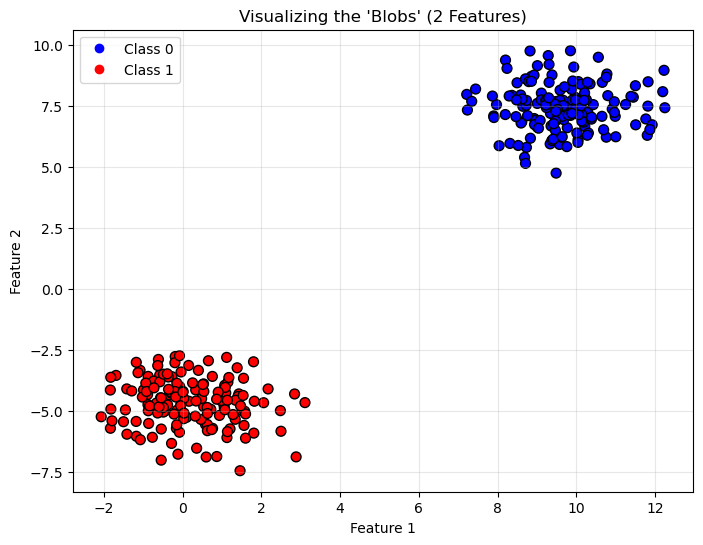

Shape of X_vis: (300, 2) (300 samples, 2 features)
Note: In the next section, we will increase n_features to 64, making the problem high-dimensional.


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

n_samples = 300
centers = 2
n_features = 2
cluster_std = 1.0
# 1. Generate 2D simplified data for visualization
X_vis, y_vis = make_blobs(n_samples=n_samples, centers=centers, n_features=n_features, cluster_std=cluster_std, random_state=2020)

# 2. Plot the data
plt.figure(figsize=(8, 6))
# Scatter plot: x-axis = feature 1, y-axis = feature 2, color = class label
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='bwr', edgecolor='k', s=50)
plt.title("Visualizing the 'Blobs' (2 Features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(handles=scatter.legend_elements()[0], labels=['Class 0', 'Class 1'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"Shape of X_vis: {X_vis.shape} (300 samples, 2 features)")
print("Note: In the next section, we will increase n_features to 64, making the problem high-dimensional.")

## Part 1: Binary Classification (Baseline)

We start with the provided textbook example. We generate a dataset using `make_blobs` with 2 centers (binary).
The network architecture uses **Sigmoid** activation at the output because we need a probability between 0 and 1.

### 1. Prepare Data

In [3]:
# 1. Prepare Data
samples = 5000
X, y = make_blobs(n_samples=samples, centers=2, n_features=64, cluster_std=10, random_state=2020)
y = y.reshape(-1,1)

# Convert to Tensors
X, y = tch.from_numpy(X).float(), tch.from_numpy(y).float()
print(X.shape)
print(y.shape)

# Split Data (in this example we split into train/validate/test sets using the ratios 70/10/20)
train_split = int(samples * 0.7)
val_split = int(samples * 0.1)

X_train, X_val, X_test = X[:train_split], X[train_split:train_split+val_split], X[train_split+val_split:]
Y_train, Y_val, Y_test = y[:train_split], y[train_split:train_split+val_split], y[train_split+val_split:]


torch.Size([5000, 64])
torch.Size([5000, 1])


### 2. Define Model

In [4]:
# 2. Define Model
class BinaryNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 1024)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(1024, 1)   # Output 1 neuron for binary
        self.final = nn.Sigmoid()       # Sigmoid squashes output to [0,1]

    def forward(self, x):
        op = self.fc1(x)
        op = self.relu1(op)
        op = self.fc2(op)
        op = self.relu2(op)
        op = self.out(op)
        y = self.final(op)
        return y

### 3. Train with different optimizers

In [5]:
# 3. Train with different Optimizers
loss_function = nn.BCELoss() # Binary Cross Entropy
num_epochs = 20
batch_size = 16

# Experiment: Adam vs SGD
print("Training with Adam...")
model_adam = BinaryNN()
opt_adam = tch.optim.Adam(model_adam.parameters(), lr=0.001)
loss_adam = train_network(model_adam, opt_adam, loss_function, num_epochs, batch_size, X_train, Y_train, X_val, Y_val)

print("\nTraining with SGD...")
model_sgd = BinaryNN()
opt_sgd = tch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
loss_sgd = train_network(model_sgd, opt_sgd, loss_function, num_epochs, batch_size, X_train, Y_train, X_val, Y_val)


Training with Adam...
Epoch: 1 - Time: 1.9232s  - Train Loss: 0.0307  - Val Loss: 0.0004 
Epoch: 5 - Time: 0.6635s  - Train Loss: 0.0000  - Val Loss: 0.0000 
Epoch: 10 - Time: 0.6885s  - Train Loss: 0.0000  - Val Loss: 0.0000 
Epoch: 15 - Time: 0.6773s  - Train Loss: 0.0000  - Val Loss: 0.0000 
Epoch: 20 - Time: 0.9702s  - Train Loss: 0.0000  - Val Loss: 0.0000 

Training with SGD...
Epoch: 1 - Time: 0.4122s  - Train Loss: 0.0911  - Val Loss: 0.2276 
Epoch: 5 - Time: 0.3344s  - Train Loss: 0.0000  - Val Loss: 0.0495 
Epoch: 10 - Time: 0.4152s  - Train Loss: 0.0000  - Val Loss: 0.0496 
Epoch: 15 - Time: 0.4509s  - Train Loss: 0.0000  - Val Loss: 0.0496 
Epoch: 20 - Time: 0.4823s  - Train Loss: 0.0000  - Val Loss: 0.0497 


### 4. Visualize training loss

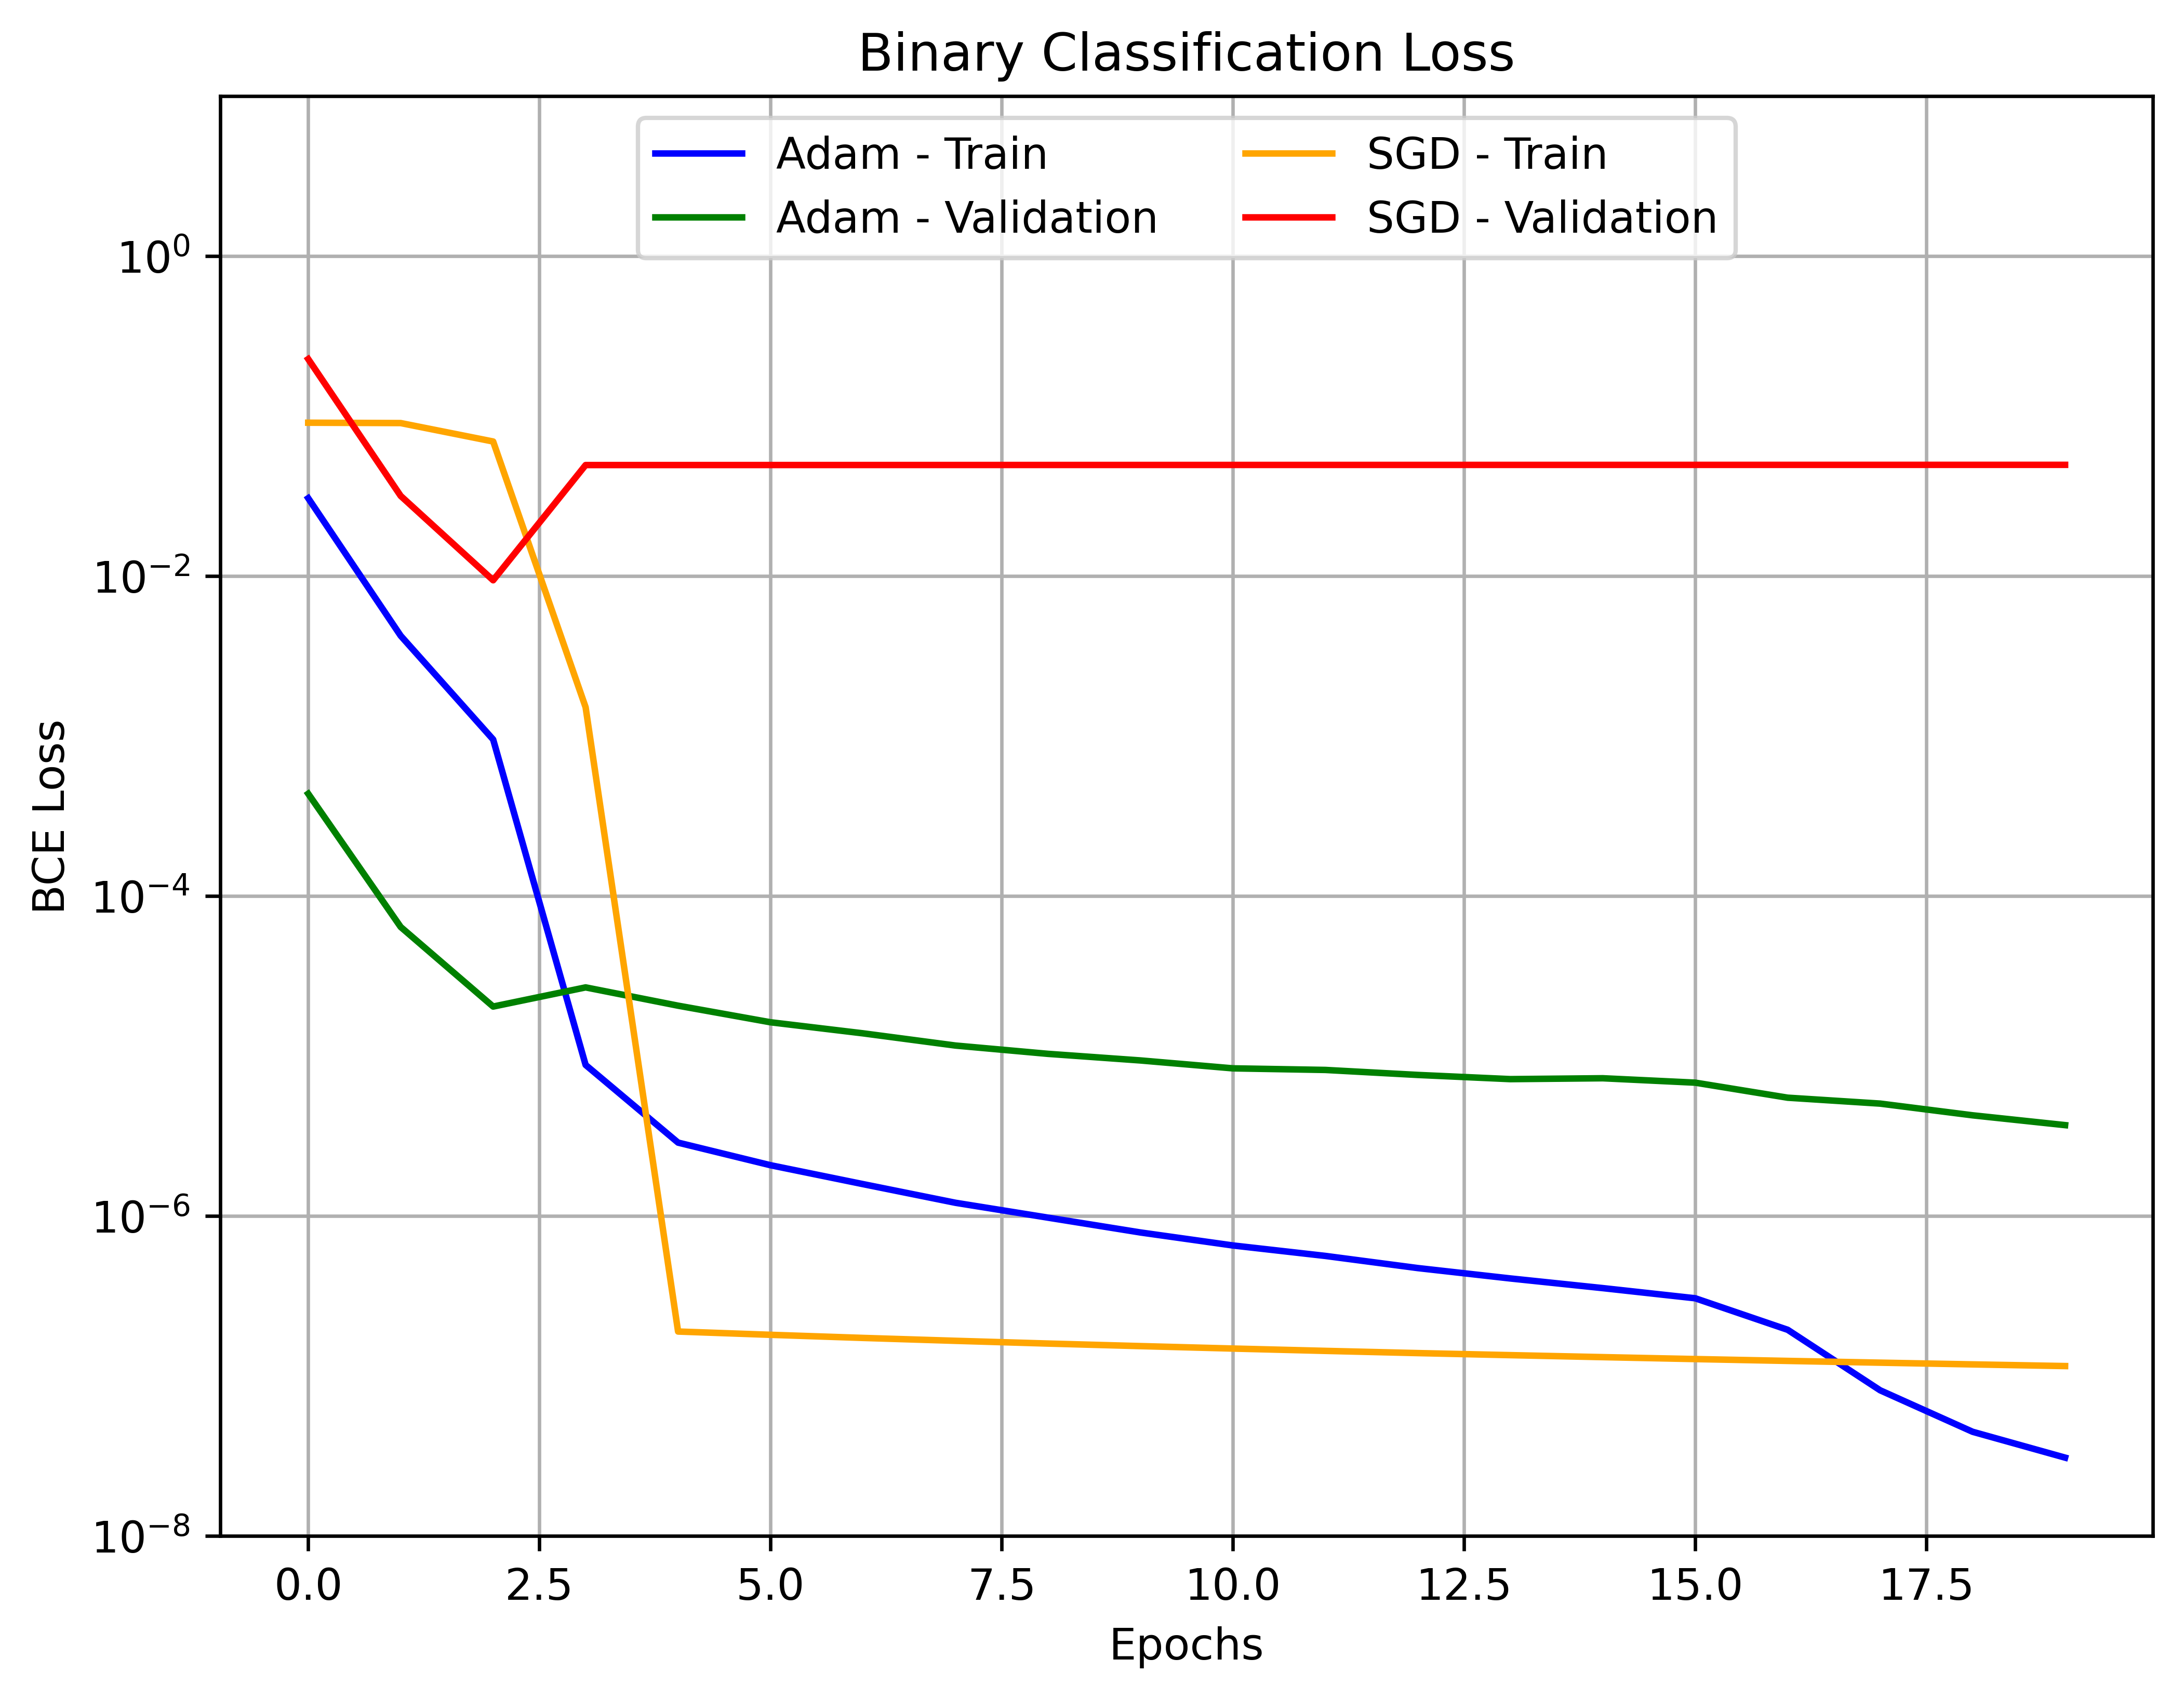

In [6]:
# 4. Visualize
plt.figure(figsize=[8,6], dpi=600)
plt.plot(loss_adam[0], "-", label="Adam - Train", color='blue')
plt.plot(loss_adam[1], label="Adam - Validation",color= 'green')

plt.plot(loss_sgd[0], "-", label="SGD - Train", color='orange')
plt.plot(loss_sgd[1], label="SGD - Validation", color ='red')

plt.legend(ncol=2, loc="upper center")
plt.title("Binary Classification Loss")
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.ylim([1e-8, 10])
plt.yscale("log")
plt.grid()
plt.savefig("part1_loss.png", dpi=600) # Save figure
plt.show()


## **Task A (Binary Classification)** [30 marks total]
**Goal**: Implement a test function and compare the performance of different optimisation algorithms (`Adam` vs. `SGD`) on a high-dimensional binary dataset.

### Instructions:

### 1. Code Implementation:

- Modify the visualization code above to also plot the validation losses for each of the optimizers being considered. [Hint: note that visualization above is currently plotting the first dimension (dimension 0 in python) of the return values from the calls to `train_network` -- the validation loss is returned as the second return value from `train_network`.]
- Using the `train_network` function as a template, write a new function called `test_loss(model, loss_function, X_test, Y_test, batch_size)`. This function should calculate and return the average loss on the test set. Ensure the model is in evaluation mode (`model.eval()`) and gradients are not being calculated (`torch.no_grad()`) during this phase.

### 2. Comparative Experiment:
- Train your model twice: once using the Adam optimizer and once using SGD (Stochastic Gradient Descent).
- Print the final test loss for both.

### 3. PDF Submission Requirements:

- **Snippets**: Include your modifications to the visualization code and your new `test_loss` function code. [5 marks each]
- **Plots**: Provide the training **and validation** loss curves for both the Adam and SGD runs. [5 marks]
- **Discussion**: Include the test losses for both Adam and SGD and address the following questions in your discussion.


### 4. Discussion:
- Which optimiser resulted in a lower test loss? Explain why that specific algorithm might be better suited for this dataset. [5 marks]

- Observe the training vs. validation loss curves. Did you notice any "gap" between them? Discuss what this suggests about overfitting or underfitting. [5 marks]

- Discuss the trade-off between **accuracy** and **compute cost**. For example, did one algorithm converge (reach a low loss) in fewer epochs than the other? [5 marks]

In [7]:
# CODE FOR TEST LOSS - ANSWER

def test_loss(model, loss_function, X_test, Y_test, batch_size):
    model.eval() # Use evalution mode from class
    total_loss = 0.0
    correct = 0
    total = 0

    with tch.no_grad(): # Don't calculate gradients
        for i in range(0, len(X_test), batch_size):
            X_batch = X_test[i:i + batch_size]
            Y_batch = Y_test[i:i + batch_size]

            outputs = model(X_batch)
            loss = loss_function(outputs, Y_batch)
            total_loss += loss.item()

    avg_loss = total_loss / ((len(X_test) + batch_size - 1) // batch_size)

    return avg_loss

test_loss_value_adam = test_loss(model_adam, loss_function, X_test, Y_test, batch_size)
test_loss_value_sgd = test_loss(model_sgd, loss_function, X_test, Y_test, batch_size)

print(f"Adam:")
print(f"Test loss: {test_loss_value_adam:.8f}")
print(f"\n")
print(f"SGD:")
print(f"Test loss: {test_loss_value_sgd:.8f}")

with open("p1test.txt", "w") as f:
    f.write(f"Adam:\n")
    f.write(f"Test loss: {test_loss_value_adam:.8f}\n")
    f.write(f"\n")
    f.write(f"SGD:\n")
    f.write(f"Test loss: {test_loss_value_sgd:.8f}\n")

Adam:
Test loss: 0.00000441


SGD:
Test loss: 0.02323385


## Part 2: Multiclass Classification

We now increase the complexity. We will generate blobs with **4 centers**.
To handle this, we must change:
1.  **The Output Layer:** It needs 4 neurons (one score per class).
2.  **The Activation/Loss:** We remove the Sigmoid. We use `CrossEntropyLoss`, which expects raw scores (logits) and class indices (not one-hot vectors).

 ### 1. Prepare Data (4 Centers)

In [4]:
# 1. Prepare Data - Updated (centers=20, cluster_std=20, n_features=128)
# Note: y is NOT reshaped to (-1, 1) here because CrossEntropyLoss expects a 1D array of class indices
samples = 5000
centers = 20
n_features = 128 # Global definition for model change
X_mc, y_mc = make_blobs(n_samples=samples, centers=centers , n_features=n_features, cluster_std=20, random_state=2020)

X_mc = tch.from_numpy(X_mc).float()
y_mc = tch.from_numpy(y_mc).long() # Targets must be Long (integers) for CrossEntropy
print(X_mc.shape)
print(y_mc.shape)
print(y_mc[0:9])

# Split Data (train/val/test, 70/10/20)
train_split = int(samples * 0.7)
val_split = int(samples * 0.1)
X_train_mc, X_val_mc, X_test_mc = X_mc[:train_split], X_mc[train_split:train_split+val_split], X_mc[train_split+val_split:]
Y_train_mc, Y_val_mc, Y_test_mc = y_mc[:train_split], y_mc[train_split:train_split+val_split], y_mc[train_split+val_split:]


torch.Size([5000, 128])
torch.Size([5000])
tensor([19, 15,  0, 10, 11,  5,  5, 11,  3])


### 2. Define Multiclass Model

In [9]:
# 2. Define Multiclass Model
class MulticlassNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 1024)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(1024, num_classes)
        # No Sigmoid here! CrossEntropyLoss handles the Softmax internally.

    def forward(self, x):
        op = self.relu1(self.fc1(x))
        op = self.relu2(self.fc2(op))
        op = self.out(op)
        return op

### 3. Train

In [14]:
# 3. Train
num_classes=centers # CHANGED: Defined globally for use in .txt file naming
model_mc = MulticlassNN(num_classes)
loss_fn_mc = nn.CrossEntropyLoss()
optimizer_mc = tch.optim.Adam(model_mc.parameters(), lr=0.001)

num_epochs = 50
print("Training Multiclass Network...")
loss_history_mc = train_network(model_mc, optimizer_mc, loss_fn_mc, num_epochs, batch_size, X_train_mc, Y_train_mc, X_val_mc, Y_val_mc)


Training Multiclass Network...
Epoch: 1 - Time: 0.2411s  - Train Loss: 1.5180  - Val Loss: 1.0201 
Epoch: 5 - Time: 0.2605s  - Train Loss: 0.1403  - Val Loss: 1.5459 
Epoch: 10 - Time: 0.2568s  - Train Loss: 0.1536  - Val Loss: 2.3666 
Epoch: 15 - Time: 0.3430s  - Train Loss: 0.1252  - Val Loss: 2.6326 
Epoch: 20 - Time: 0.4604s  - Train Loss: 0.2370  - Val Loss: 3.6235 
Epoch: 25 - Time: 0.6160s  - Train Loss: 0.0640  - Val Loss: 3.8229 
Epoch: 30 - Time: 1.0068s  - Train Loss: 0.2467  - Val Loss: 5.7219 
Epoch: 35 - Time: 1.0191s  - Train Loss: 0.1937  - Val Loss: 7.1357 
Epoch: 40 - Time: 1.1127s  - Train Loss: 0.0917  - Val Loss: 7.1280 
Epoch: 45 - Time: 1.6469s  - Train Loss: 0.1659  - Val Loss: 7.2757 
Epoch: 50 - Time: 0.9988s  - Train Loss: 0.3315  - Val Loss: 8.8665 


### 4. Evaluation

We now evaluate the accuracy of the trained model by computing the propotion of the test set for which the correct class is predicted.

In [16]:
# 4. Evaluation
# Compute the proportion of the test set for which we predict the correct class
# To get predictions, we take the argmax of the logits
#loss_history_mc[-1].eval()
with tch.no_grad():
    logits = model_mc(X_test_mc)
    predictions = tch.argmax(logits, dim=1)
    accuracy = (predictions == Y_test_mc).float().mean()
    print(f"Test Accuracy: {accuracy:.4f}")
    #---------------- Added code for loss
    print(f"Final Training loss: {loss_history_mc[0][-1]:.10f}")
    print(f"Final Validation loss: {loss_history_mc[1][-1]:.6f}")
    with open(f"p2out{num_classes}_std20_128feat.txt", "w") as f: # Save to .txt, use class no. for file name
        f.write(f"Test Accuracy: {accuracy:.4f}\n")
        f.write(f"Final Training loss: {loss_history_mc[0][-1]:.10f}\n")
        f.write(f"Final Validation loss: {loss_history_mc[1][-1]:.6f}")

Test Accuracy: 0.7540
Final Training loss: 0.3314900473
Final Validation loss: 8.866455


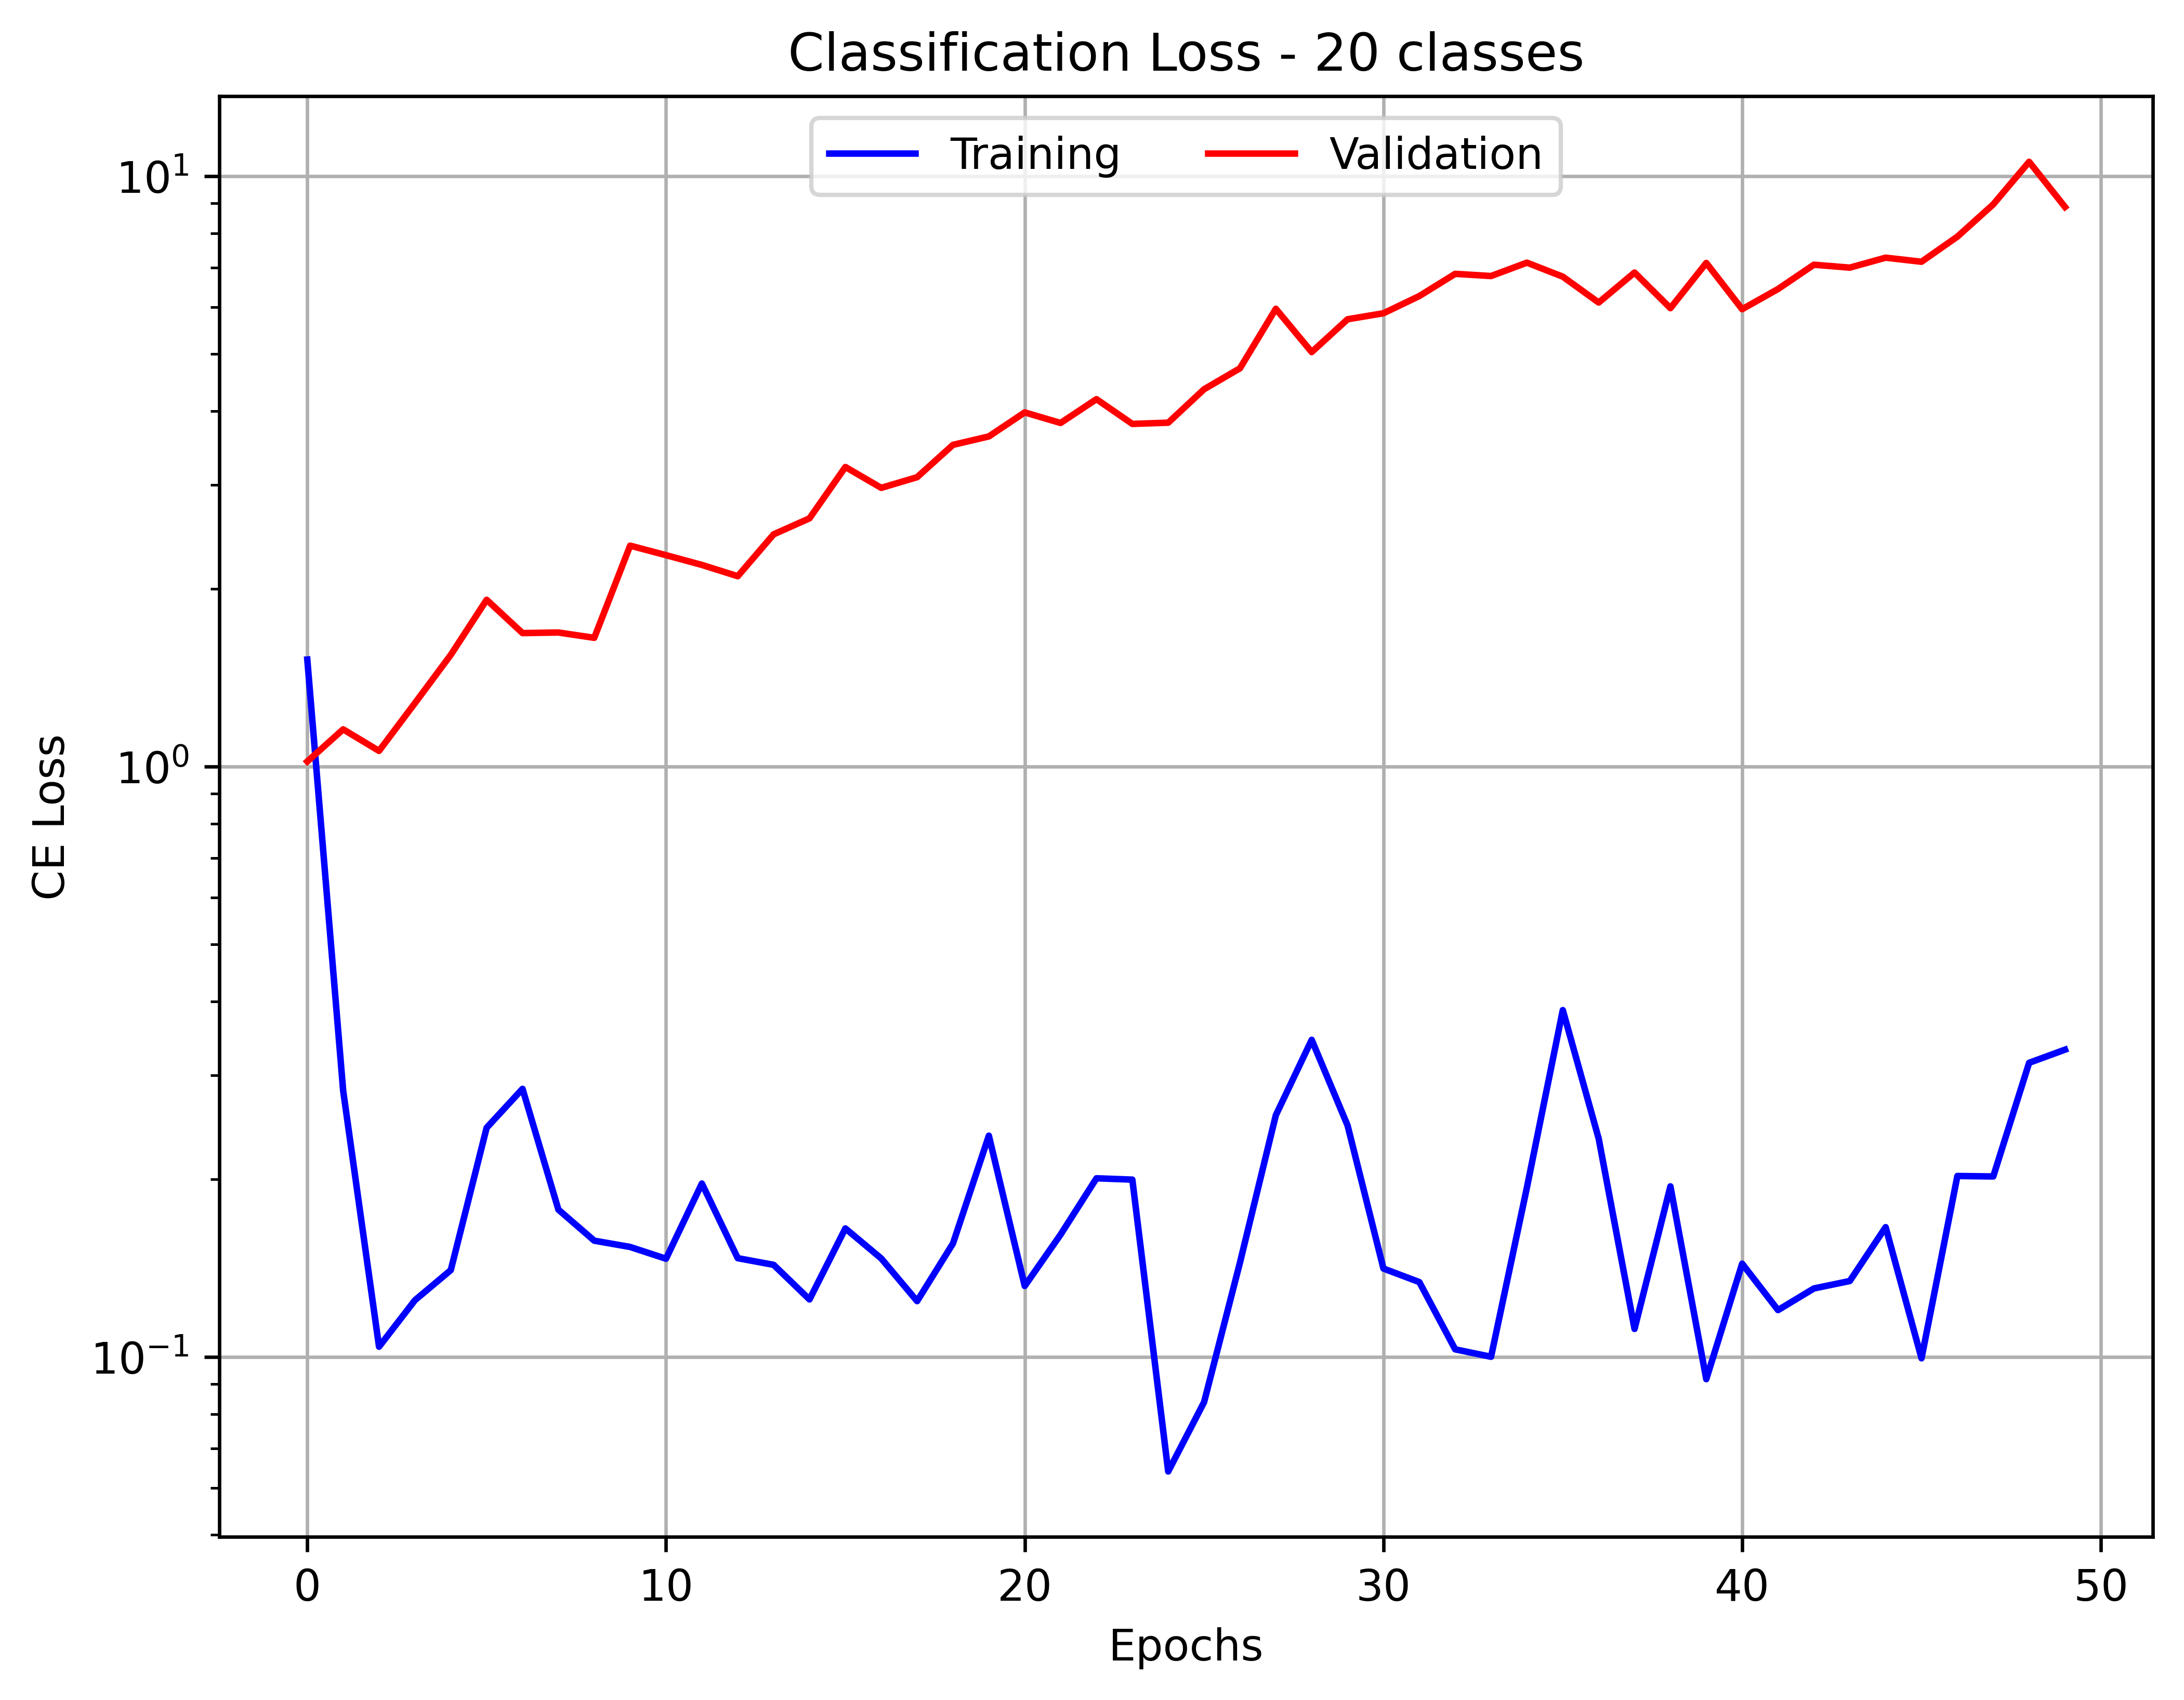

In [17]:
# 4. Visualize
plt.figure(figsize=[8,6], dpi=600)
plt.plot(loss_history_mc[0], "-", label="Training", color='blue')
plt.plot(loss_history_mc[1], label="Validation",color= 'red')


plt.legend(ncol=2, loc="upper center")
plt.title(f"Classification Loss - {num_classes} classes")
plt.xlabel("Epochs")
plt.ylabel("CE Loss")
#plt.ylim([1e-8, 10])
plt.yscale("log")
plt.grid()
plt.savefig(f"part2_loss_centers{num_classes}_std20_128feat.png", dpi=600) # Save figure
plt.show()

## **Task B Data Complexity (Multiclass Classification)** [30 marks total]
**Goal**: Investigate how increasing the complexity of a multiclass dataset through, more classes, higher data variance, and increased dimensionality affects a neural network's performance.

**Instructions**: You will modify the parameters of the  `make_blobs` generator and discuss the resulting impact on model accuracy and loss.

1.  **Experiment 1: Increasing Class Density** [10 marks]
    - **Action**: Modify `centers` to use **20** (representing 20 distinct classes) instead of the original 4-class version
    - **PDF Requirement**: Include code snippets where you modified this parameter, screenshots of the final Train/Val Loss and the accuracy, and discuss the following.
    - **Discussion**: Discuss the training and validation losses and the test accuracy compared to the 4-class version? Why does increasing the number of output categories make the classification task more difficult for the network?

2.  **Experiment 2: Increasing Data Noise (Standard Deviation)** [10 marks]
    - **Action**: Keep the number of classes at 20, but increase the `cluster_std` (cluster standard deviation) to **20**.
    - **PDF Requirement**: Include code snippets where you modified this parameter, screenshots of the final Train/Val Loss and the accuracy, and discuss the following.
    - **Discussion**: Compare this result to a run with 10 cluster_std and discuss the training and validation losses, and the test accuracy? Why does increasing the class standard deviation make the classification task more difficult for the network?

3.  **Experiment 3: High-Dimensional Input Space** [10 marks]
    - **Action**: Using the settings from Experiment 2 (20 classes, 20 cluster_std), increase the `n_features` to **128**.
    - **PDF Requirement**: Include code snippets where you modified this parameter, screenshots of the final Train/Val Loss and the accuracy, and discuss the following.
    - **Discussion**: What effect does increasing the number of features (dimensionality) have compared to the previous experiment? Discuss why having more features might help or hinder the model when dealing with noisy, overlapping clusters.

## Part 3: Regression

Finally, we change the problem type entirely. Instead of classifying dots, we want to predict a continuous value.
We use `make_regression` to create the data.
Changes required:
1.  **Output Layer:** 1 neuron (predicting one value).
2.  **Activation:** None (Linear). We want the network to be able to output any number, not just 0-1.
3.  **Loss Function:** `MSELoss` (Mean Squared Error).

### 1. Prepare Data

In [5]:
# 1. Prepare Data (Regression)
X_reg, y_reg = make_regression(n_samples=5000, n_features=64, noise=2, random_state=2020)
y_reg = y_reg.reshape(-1, 1) # Reshape for consistency with output layer

X_reg = tch.from_numpy(X_reg).float()
y_reg = tch.from_numpy(y_reg).float()

samples = X_reg.shape[0]
# Split Data (train/val/test, 70/10/20)
train_split = int(samples * 0.7)
val_split = int(samples * 0.1)

X_train_reg, X_val_reg, X_test_reg = X_reg[:train_split], X_reg[train_split:train_split+val_split], X_reg[train_split+val_split:]
Y_train_reg, Y_val_reg, Y_test_reg = y_reg[:train_split], y_reg[train_split:train_split+val_split], y_reg[train_split+val_split:]


### 2. Define Regression Model

In [6]:
# 2. Define Regression Model
class RegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 1024)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(1024, 1)
        # No Final Activation (Linear)

    def forward(self, x):
        op = self.relu1(self.fc1(x))
        op = self.relu2(self.fc2(op))
        op = self.out(op)
        return op

In [7]:
# 2b. Define Regression Model - GELU
class GELURegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256)
        self.gelu1 = nn.GELU()
        self.fc2 = nn.Linear(256, 1024)
        self.gelu2 = nn.GELU()
        self.out = nn.Linear(1024, 1)
        # No Final Activation (Linear)

    def forward(self, x):
        op = self.gelu1(self.fc1(x))
        op = self.gelu2(self.fc2(op))
        op = self.out(op)
        return op

### 3. Train

In [12]:
# 3. Train
model_relu = RegressionNN()
model_gelu = GELURegressionNN()
loss_fn_reg = nn.MSELoss()
optimizer_relu = tch.optim.Adam(model_relu.parameters(), lr=0.0001)
optimizer_gelu = tch.optim.Adam(model_gelu.parameters(), lr=0.0001) # Requires seperate optimizer definition
batch_size = 32
print("Training Regression Network (ReLU)...")
num_epochs = 150
#loss_relu = train_network(model_relu, optimizer_relu, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)
print("Training Regression Network (GELU)...")
#loss_gelu = train_network(model_gelu, optimizer_gelu, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)

Training Regression Network (ReLU)...
Training Regression Network (GELU)...


In [ ]:
with open(f"p3out.txt", "w") as f: # Save to .txt
    f.write("ReLU:\n")
    f.write(f"Final Training loss: {loss_relu[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_relu[1][-1]:.4f}\n")
    f.write("GELU:\n")
    f.write(f"Final Training loss: {loss_gelu[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_gelu[1][-1]:.4f}")

# 4. Visualisation
plt.figure(figsize=(8, 5))

# ReLU model
plt.plot(loss_relu[0], label="ReLU - Train", linestyle="-", color="blue")
plt.plot(loss_relu[1], label="ReLU - Validation", linestyle="--", color="blue")

# GELU model
plt.plot(loss_gelu[0], label="GELU - Train", linestyle="-", color="orange")
plt.plot(loss_gelu[1], label="GELU - Validation", linestyle="--", color="orange")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Training and Validation Loss")
plt.ylim(0,200)
plt.xlim(0,150)
plt.legend(ncol=2, loc="upper center")
plt.grid(True)
plt.savefig("p3loss.png", dpi=600)

plt.tight_layout()
plt.show()

## **Task C: Model Architecture (Regression)** [25 marks total]

**Goal**: Evaluate how variations in model depth and the choice of activation functions impact the performance and computational efficiency of a regression network.

**Instructions**: You will go beyond the standard ReLU activation and shallow networks to implement a more complex regression architectures.

1.  **Experiment 1: Activation Function Impact** [10 marks]
    - **Action**: Create a modified version of the regression class from the notebook. Replace the standard `nn.ReLU()` activation function with `nn.GELU()` (Gaussian Error Linear Unit).
    - **PDF Requirement**: Include a side-by-side comparison of the final training and Validation losses for both the ReLU and GELU models.
    - **Analysis**: How did the change to GELU affect the smoothness of the training curve and the final loss? Research and briefly explain one theoretical advantage of GELU over ReLU.

2.  **Experiment 2: Increasing Model Depth** [10 marks]
    - **Action**: Define a new class named `DeeperRegression`. This model must use `nn.GELU()` and include two hidden layers (e.g., Input &rarr; Hidden 1 &rarr; Hidden 2 &rarr; Output) instead of the original single hidden layer. (Use `nn.Linear(1024, 1024)` for Hidden 2 )
    - **PDF Requirement**: Provide a screenshot of your `DeeperRegression` class definition in PyTorch.
    - **Analysis**: Compare the training and validation loss curves of this deeper model to the single-layer GELU model. Which model is better?

3. **Experiment 3: Performance vs. Computational Cost** [5 marks]
    - **Action**: Compare your `DeeperRegression` model against the "Original Network"- the single hidden layer model with `nn.RELU()` activation.
    - **PDF Requirement**: Include a summary of the Time per Epoch and the Final validation Loss for both architectures.
    - **Analysis**: Is the reduction in validation loss by the deeper network significant enough to justify the increased computational time per epoch?

In [21]:
## TASK C
#Define Deep Regression Model
class DeeperRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(64, 256)
        self.gelu1 = nn.GELU()
        self.fc2 = nn.Linear(256, 1024)
        self.gelu2 = nn.GELU()
        self.fc3 = nn.Linear(1024, 1024)
        self.gelu3 = nn.GELU()
        self.out = nn.Linear(1024, 1)
        # No Final Activation (Linear)

    def forward(self, x):
        op = self.gelu1(self.fc1(x))
        op = self.gelu2(self.fc2(op))
        op = self.gelu3(self.fc3(op))
        op = self.out(op)
        return op

In [22]:
# Train
model_deep = DeeperRegression()
loss_fn_reg = nn.MSELoss()
optimizer_deep = tch.optim.Adam(model_deep.parameters(), lr=0.0001)
batch_size = 32
print("Training Regression Network (Deeper)...")
num_epochs = 150
loss_deep = train_network(model_deep, optimizer_deep, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)

Training Regression Network (Deeper)...


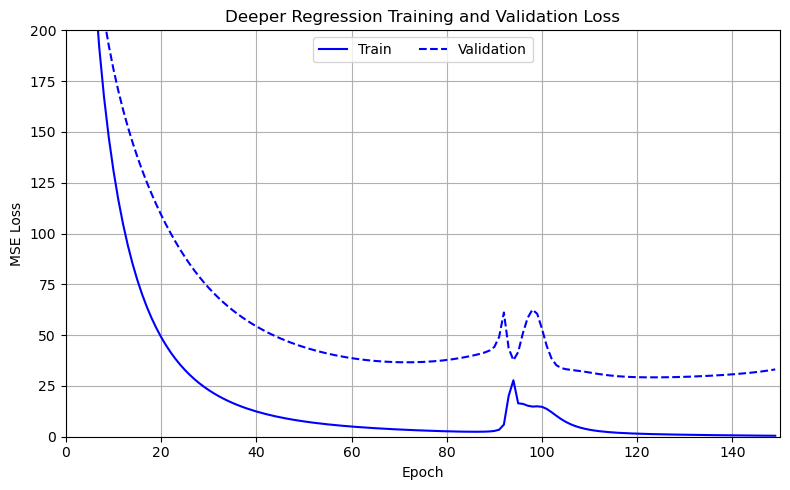

In [31]:
with open(f"p3out_deep.txt", "w") as f: # Save to .txt
    f.write("Deeper Regression:\n")
    f.write(f"Final Training loss: {loss_deep[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_deep[1][-1]:.4f}\n")

# 4. Visualisation
plt.figure(figsize=(8, 5))
plt.plot(loss_deep[0], label="Train", linestyle="-", color="blue")
plt.plot(loss_deep[1], label="Validation", linestyle="--", color="blue")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Deeper Regression Training and Validation Loss")
plt.ylim(0,200)
plt.xlim(0,150)
plt.legend(ncol=2, loc="upper center")
plt.grid(True)
plt.savefig("p3loss_deep.png", dpi=600)

plt.tight_layout()
plt.show()

In [13]:
# ReLU model
start = time.time()
loss_relu = train_network(model_relu, optimizer_relu, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)
avg_relu_time = (time.time() - start) / num_epochs

# GELU model
start = time.time()
loss_gelu = train_network(model_gelu, optimizer_gelu, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)
avg_gelu_time = (time.time() - start) / num_epochs

# Deeper model
start = time.time()
loss_deep = train_network(model_deep, optimizer_deep, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)
avg_deep_time = (time.time() - start) / num_epochs


Epoch: 1 - Time: 0.1374s  - Train Loss: 21695.9320  - Val Loss: 22893.5037 
Epoch: 5 - Time: 0.1156s  - Train Loss: 5385.0743  - Val Loss: 3494.3071 
Epoch: 10 - Time: 0.1204s  - Train Loss: 177.4670  - Val Loss: 193.8878 
Epoch: 15 - Time: 0.1159s  - Train Loss: 89.9315  - Val Loss: 122.9665 
Epoch: 20 - Time: 0.1085s  - Train Loss: 57.1026  - Val Loss: 95.6845 
Epoch: 25 - Time: 0.1043s  - Train Loss: 39.3880  - Val Loss: 80.6945 
Epoch: 30 - Time: 0.1547s  - Train Loss: 28.3250  - Val Loss: 71.0190 
Epoch: 35 - Time: 0.1255s  - Train Loss: 20.8933  - Val Loss: 64.3458 
Epoch: 40 - Time: 0.1066s  - Train Loss: 15.6644  - Val Loss: 59.3150 
Epoch: 45 - Time: 0.1082s  - Train Loss: 11.8495  - Val Loss: 55.5298 
Epoch: 50 - Time: 0.1285s  - Train Loss: 8.9885  - Val Loss: 52.6948 
Epoch: 55 - Time: 0.1288s  - Train Loss: 6.7997  - Val Loss: 50.5271 
Epoch: 60 - Time: 0.1038s  - Train Loss: 5.1168  - Val Loss: 48.8535 
Epoch: 65 - Time: 0.1192s  - Train Loss: 3.8084  - Val Loss: 47.6002 

NameError: name 'model_deep' is not defined

In [39]:
print(f"Avg epoch time (ReLU):  {avg_relu_time:.4f} s")
print(f"Avg epoch time (GELU):  {avg_gelu_time:.4f} s")
print(f"Avg epoch time (Deep):  {avg_deep_time:.4f} s")

with open("p3epoch_times.txt", "w") as f:
    f.write(f"ReLU:  {avg_relu_time:.4f} s/epoch\n")
    f.write(f"Final Training loss: {loss_relu[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_relu[1][-1]:.4f}\n")
    f.write(f"GELU:  {avg_gelu_time:.4f} s/epoch\n")
    f.write(f"Final Training loss: {loss_gelu[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_gelu[1][-1]:.4f}\n")
    f.write(f"Deep:  {avg_deep_time:.4f} s/epoch\n")
    f.write(f"Final Training loss: {loss_deep[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_deep[1][-1]:.4f}\n")

Avg epoch time (ReLU):  0.1362 s
Avg epoch time (GELU):  0.1897 s
Avg epoch time (Deep):  0.7172 s


## **Task D: Hyperparameters and Computational Cost** [15 marks total]

**Goal**: Explore the relationship between training duration, batch dynamics, and optimization strategies to maximize model performance while managing compute resources.

**Instructions**: This final task focuses on the "tuning" phase of machine learning. You will use your single layer with `nn.GELU()` model to test how global hyperparameters change the learning behavior.

1. **Experiment 1: The Impact of Extended Training** [5 marks]
    - **Action**: In your regression setup, increase the num_epochs to 250.
    - **PDF Requirement**: Include a screenshot of the loss curve extending to 250 epochs.
    - **Analysis**: Compare this to your previous shorter run (150 epochs).  What effect does training for a longer time have on the training and validation loss? Does the validation loss continue to drop, or does it plateau/start to rise? What does this tell you about the risk of overfitting when training for too many epochs?

2. **Experiment 2: Batch Size Dynamics** [5 marks]
    - **Action**: Change the batch_size from 32 to 256.
    - **PDF Requirement**: Include a screenshot of the loss curve for this larger batch size.
    - **Analysis**: Compare the training and validation losses curves, and time per epoch. Discuss the tradeoff between accuracy and cost.

3.  **Experiment 3: Advanced Optimization (Learning Rate & Schedulers)** [5 marks]
    - **Action**: Attempt to improve the performance of your DeeperRegression model by varying the learning_rate of the optimiser using Learning Rate Scheduler  (`torch.optim.lr_scheduler.StepLR`).
    - **PDF Requirement**: Provide the code snippet showing your chosen Scheduler implementation. Provide the final validation loss achieved with this optimisation.
    - **Analysis**: How did the Scheduler affect the final stages of training? Did it allow the model to reach a lower loss than a fixed learning rate?

In [14]:
# TASK D
model_gelu_ext = GELURegressionNN() # New instance of the same network
loss_fn_reg = nn.MSELoss()
optimizer_gelu_ext = tch.optim.Adam(model_gelu_ext.parameters(), lr=0.0001)
batch_size = 256
num_epochs = 150
print("Training Regression Network (GELU)...")
start = time.time()
loss_gelu_ext = train_network(model_gelu_ext, optimizer_gelu_ext, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg)
avg_256batch_time = (time.time() - start) / num_epochs

Training Regression Network (GELU)...
Epoch: 1 - Time: 0.0598s  - Train Loss: 22132.7874  - Val Loss: 22962.2300 
Epoch: 5 - Time: 0.0426s  - Train Loss: 21978.9636  - Val Loss: 22786.8950 
Epoch: 10 - Time: 0.0424s  - Train Loss: 21174.3163  - Val Loss: 21879.6660 
Epoch: 15 - Time: 0.0479s  - Train Loss: 18449.6656  - Val Loss: 18977.6110 
Epoch: 20 - Time: 0.0450s  - Train Loss: 13373.0410  - Val Loss: 13815.4300 
Epoch: 25 - Time: 0.0414s  - Train Loss: 7819.0309  - Val Loss: 8226.2782 
Epoch: 30 - Time: 0.0462s  - Train Loss: 3700.2794  - Val Loss: 4046.3477 
Epoch: 35 - Time: 0.0404s  - Train Loss: 1597.6880  - Val Loss: 1866.0612 
Epoch: 40 - Time: 0.0487s  - Train Loss: 805.7089  - Val Loss: 999.9931 
Epoch: 45 - Time: 0.0747s  - Train Loss: 511.5321  - Val Loss: 658.2722 
Epoch: 50 - Time: 0.0419s  - Train Loss: 370.5125  - Val Loss: 492.6347 
Epoch: 55 - Time: 0.0886s  - Train Loss: 284.9004  - Val Loss: 394.1097 
Epoch: 60 - Time: 0.2652s  - Train Loss: 226.4985  - Val Loss:

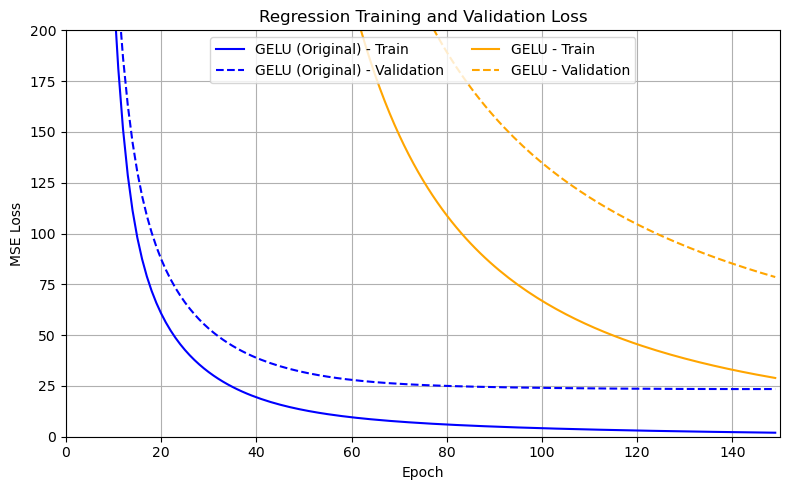

In [15]:
with open(f"p4e2out.txt", "w") as f: # Save to .txt
    f.write("GELU (32 batch):\n")
    f.write(f"Average time per epoch: {avg_gelu_time:.4f} s/epoch\n")
    f.write(f"Final Training loss: {loss_gelu[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_gelu[1][-1]:.4f}\n")
    f.write("GELU (256 batch):\n") 
    f.write(f"Average time per epoch: {avg_256batch_time:.4f} s/epoch\n")
    f.write(f"Final Training loss: {loss_gelu_ext[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_gelu_ext[1][-1]:.4f}\n")

# 4. Visualisation
plt.figure(figsize=(8, 5))

# GELU model
plt.plot(loss_gelu[0], label="GELU (Original) - Train", linestyle="-", color="blue")
plt.plot(loss_gelu[1], label="GELU (Original) - Validation", linestyle="--", color="blue")

plt.plot(loss_gelu_ext[0], label="GELU - Train", linestyle="-", color="orange")
plt.plot(loss_gelu_ext[1], label="GELU - Validation", linestyle="--", color="orange")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Training and Validation Loss")
plt.ylim(0,200)
plt.xlim(0,150)
plt.legend(ncol=2, loc="upper center")
plt.grid(True)
plt.savefig("p4e2loss.png", dpi=600)

plt.tight_layout()
plt.show()

In [55]:
# Train
model_deep_lrs = DeeperRegression()
loss_fn_reg = nn.MSELoss()
optimizer_deep_lrs = tch.optim.Adam(model_deep_lrs.parameters(), lr=0.0001)
scheduler = tch.optim.lr_scheduler.StepLR(optimizer_deep_lrs, step_size=25, gamma=0.5)
batch_size = 32
print("Training Regression Network (Deeper)...")
num_epochs = 150
loss_deep_lrs = train_network(model_deep_lrs, optimizer_deep_lrs, loss_fn_reg, num_epochs, batch_size, X_train_reg, Y_train_reg, X_val_reg, Y_val_reg, scheduler=scheduler)

Training Regression Network (Deeper)...
Epoch: 1 - Time: 0.6534s  - Train Loss: 21236.4270  - Val Loss: 20225.7747 
Epoch: 5 - Time: 0.5185s  - Train Loss: 291.0866  - Val Loss: 305.2558 
Epoch: 10 - Time: 0.5258s  - Train Loss: 128.5281  - Val Loss: 183.7678 
Epoch: 15 - Time: 0.6305s  - Train Loss: 75.0873  - Val Loss: 131.6669 
Epoch: 20 - Time: 0.5755s  - Train Loss: 47.0961  - Val Loss: 100.4319 
Epoch: 25 - Time: 0.5589s  - Train Loss: 31.0765  - Val Loss: 79.7461 
Epoch: 30 - Time: 0.5483s  - Train Loss: 23.7957  - Val Loss: 69.0999 
Epoch: 35 - Time: 0.5528s  - Train Loss: 19.4167  - Val Loss: 62.4047 
Epoch: 40 - Time: 0.6396s  - Train Loss: 15.8509  - Val Loss: 56.4295 
Epoch: 45 - Time: 0.5954s  - Train Loss: 12.9912  - Val Loss: 51.1919 
Epoch: 50 - Time: 0.6761s  - Train Loss: 10.7153  - Val Loss: 46.6731 
Epoch: 55 - Time: 0.8503s  - Train Loss: 9.2327  - Val Loss: 42.9696 
Epoch: 60 - Time: 0.6408s  - Train Loss: 8.3160  - Val Loss: 41.0105 
Epoch: 65 - Time: 0.6641s  - 

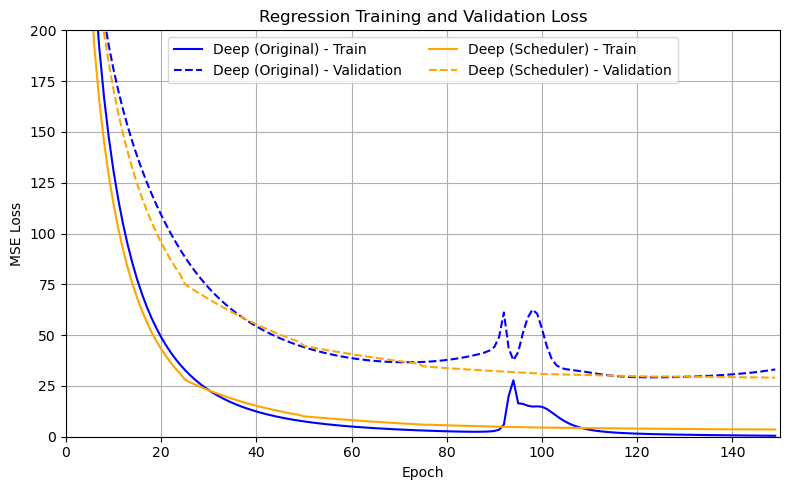

In [56]:
with open(f"p4e3out.txt", "w") as f: # Save to .txt
    f.write("Deep (No scheduler):\n")
    f.write(f"Final Training loss: {loss_deep[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_deep[1][-1]:.4f}\n")
    f.write("Deep (With scheduler):\n") 
    f.write(f"Final Training loss: {loss_deep_lrs[0][-1]:.4f}\n")
    f.write(f"Final Validation loss: {loss_deep_lrs[1][-1]:.4f}\n")

# 4. Visualisation
plt.figure(figsize=(8, 5))

# GELU model
plt.plot(loss_deep[0], label="Deep (Original) - Train", linestyle="-", color="blue")
plt.plot(loss_deep[1], label="Deep (Original) - Validation", linestyle="--", color="blue")

plt.plot(loss_deep_lrs[0], label="Deep (Scheduler) - Train", linestyle="-", color="orange")
plt.plot(loss_deep_lrs[1], label="Deep (Scheduler) - Validation", linestyle="--", color="orange")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression Training and Validation Loss")
plt.ylim(0,200)
plt.xlim(0,150)
plt.legend(ncol=2, loc="upper center")
plt.grid(True)
plt.savefig("p4e3loss.png", dpi=600)

plt.tight_layout()
plt.show()